## 1. Graph 1

In [5]:
# Setup
import pandas as pd
import matplotlib.pyplot as plt
from mwviews.api import PageviewsClient

p = PageviewsClient(user_agent="jy105@wellesley.edu)")

START = '20220601'
END   = '20240601'

In [2]:
# Create show list
shows = [
    "The Glory (TV series)",
    "Moving (South Korean TV series)",
    "My Demon",
    "King the Land",
    "Gyeongseong Creature",
    "Twinkling Watermelon",
    "Death's Game",
    "Crash Course in Romance",
    "Welcome to Samdal-ri",
    "Celebrity (South Korean TV series)",
    "A Time Called You",
    "Perfect Marriage Revenge",
    "See You in My 19th Life",
    "The Good Bad Mother",
    "My Lovely Liar",
    "Doona!",
    "Love to Hate You (TV series)",
    "Daily Dose of Sunshine",
    "Destined with You",
]

In [6]:
# Fetch pageviews for each page
data = p.article_views('en.wikipedia', shows, start=START, end=END)

In [8]:
# Add pageviews for each show to the dictionary
totals = {show: 0 for show in shows}
key = {show: show.replace(' ', '_') for show in shows}

for day, counts in data.items():
    for show in shows:
        totals[show] += counts.get(key[show]) or 0

totals

{'The Glory (TV series)': 5437126,
 'Moving (South Korean TV series)': 2891114,
 'My Demon': 2822146,
 'King the Land': 2697595,
 'Gyeongseong Creature': 2081110,
 'Twinkling Watermelon': 2061432,
 "Death's Game": 1963050,
 'Crash Course in Romance': 1488160,
 'Welcome to Samdal-ri': 1460872,
 'Celebrity (South Korean TV series)': 1441608,
 'A Time Called You': 1349860,
 'Perfect Marriage Revenge': 1266164,
 'See You in My 19th Life': 1247697,
 'The Good Bad Mother': 1172570,
 'My Lovely Liar': 1169482,
 'Doona!': 1033094,
 'Love to Hate You (TV series)': 822729,
 'Daily Dose of Sunshine': 559765,
 'Destined with You': 1156}

In [9]:
# Build sorted dataframe
pageviews_df = (
    pd.DataFrame(list(totals.items()), columns=['Show', 'Total Pageviews'])
    .sort_values('Total Pageviews', ascending=False)
    .reset_index(drop=True)
)

pageviews_df

,Show,Total Pageviews
0,The Glory (TV series),5437126
1,Moving (South Korean TV series),2891114
2,My Demon,2822146
3,King the Land,2697595
4,Gyeongseong Creature,2081110
5,Twinkling Watermelon,2061432
6,Death's Game,1963050
7,Crash Course in Romance,1488160
8,Welcome to Samdal-ri,1460872
9,Celebrity (South Korean TV series),1441608


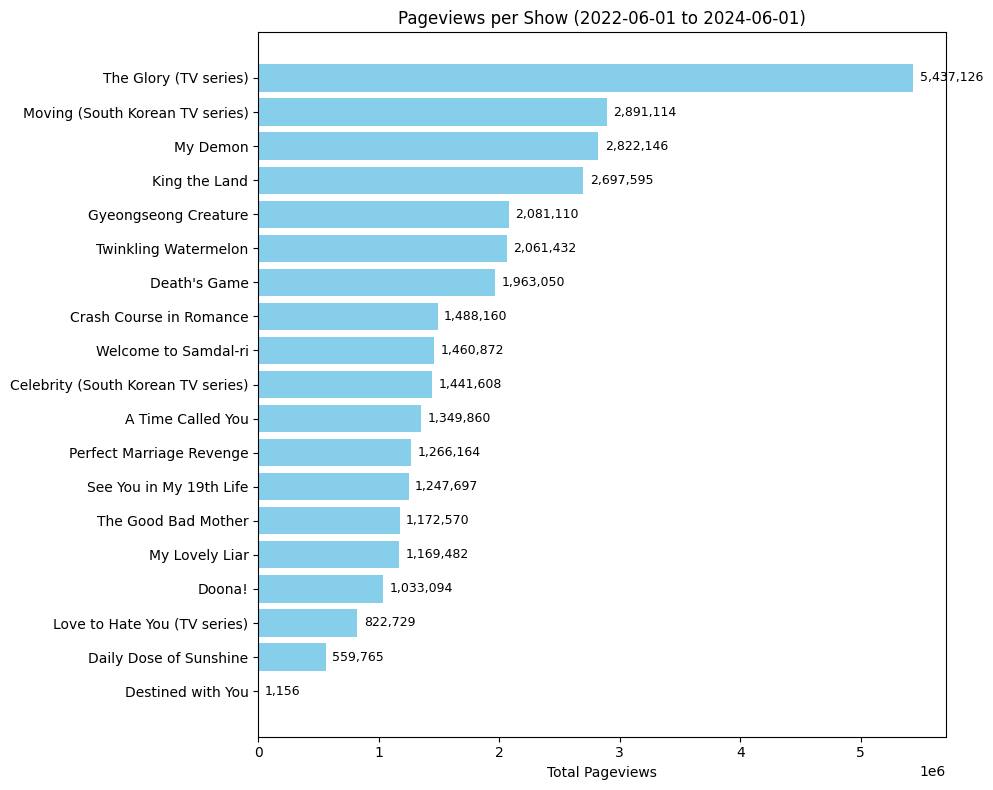

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(10, 8))

plot_df = pageviews_df.iloc[::-1]

bars = ax.barh(plot_df['Show'], plot_df['Total Pageviews'], color='skyblue')

for bar, value in zip(bars, plot_df['Total Pageviews']):
    ax.text(bar.get_width() + max(plot_df['Total Pageviews'])*0.01,
            bar.get_y() + bar.get_height()/2,
            f"{value:,}",
            va='center', fontsize=9)

ax.set_title(f"Pageviews per Show (2022-06-01 to 2024-06-01)")
ax.set_xlabel("Total Pageviews")

plt.tight_layout()
plt.show()

## Graph 2

In [ ]:
# Find daily pageview
daily = {} 

for show in shows:
    wiki_key = key[show]
    series = {day: counts.get(wiki_key) or 0 for day, counts in data.items()}
    daily[show] = pd.Series(series).sort_index()

daily[shows[0]].head()

2022-06-01    0
2022-06-02    0
2022-06-03    0
2022-06-04    0
2022-06-05    0
dtype: int64

In [16]:
# Find peak day and reindex days

aligned = {}  

for show, series in daily.items():
    peak_date = series.idxmax()
    rel_days = (series.index - peak_date).days
    aligned_series = pd.Series(series.values, index=rel_days)
    aligned_series = aligned_series[(aligned_series.index >= -120) & (aligned_series.index <= 120)]
    aligned[show] = aligned_series.sort_index()

rank = pageviews_df['Show'].tolist()

rank[:5]

['The Glory (TV series)',
 'Moving (South Korean TV series)',
 'My Demon',
 'King the Land',
 'Gyeongseong Creature']

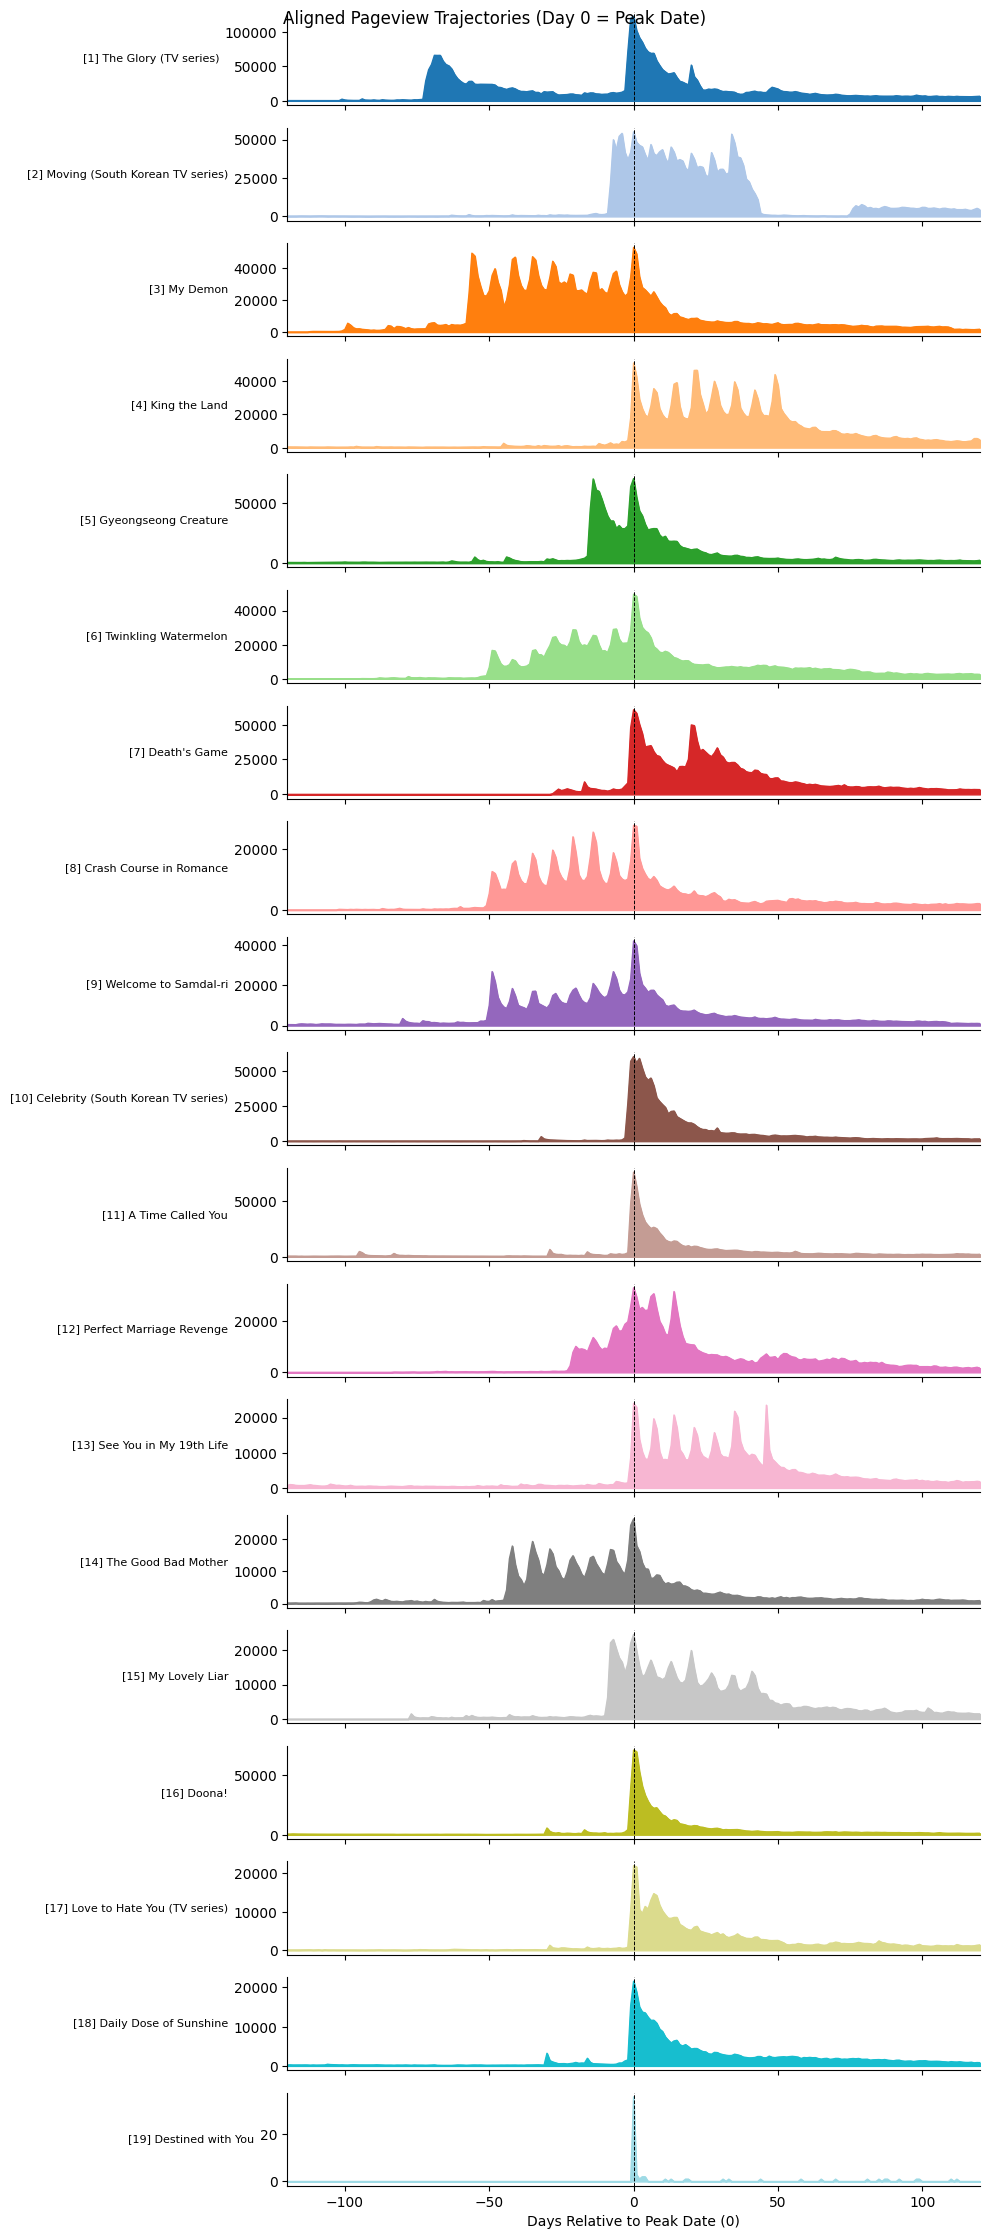

In [17]:
# Plot
import numpy as np

fig, axes = plt.subplots(
    nrows=len(rank), ncols=1,
    figsize=(10, 1.2*len(rank)),
    sharex=True
)

colors = plt.cm.tab20(np.linspace(0, 1, len(rank)))

for i, (ax, show, color) in enumerate(zip(axes, rank, colors)):
    series = aligned[show]
    ax.plot(series.index, series.values, color=color, linewidth=1)
    ax.fill_between(series.index, series.values, color=color)

    ax.axvline(0, color='black', linewidth=0.7, linestyle='--')

    rank = i + 1
    ax.set_ylabel(f"[{rank}] {show}", rotation=0, ha='right', va='center', fontsize=8)

    ax.set_xlim(-120, 120)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel("Days Relative to Peak Date (0)")
fig.suptitle("Aligned Pageview Trajectories (Day 0 = Peak Date)")

plt.tight_layout()
plt.show()